LOADING DATA FROM SU2C-MARK SOURCE FILES...

[1/3] Loading Clinical Data...
✓ Clinical data:  (393, 38)
✓ Clinical extra:  (393, 7)

[2/3] Loading SF Scores...
✓ SF scores: (152, 12)
  Columns: ['Harmonized_SU2C_RNA_Tumor_Sample_ID_v2', 'B-cells', 'Cytotoxic cells', 'DC', 'Exhausted CD8', 'Exhausted/HS CD8', 'Lymphocytes', 'Lymphocytes exhausted/cell cycle', 'Macrophages/Monocytes', 'Memory T cells', 'Plasma', 'Treg']

[3/3] Loading ZI Scores...
✓ ZI scores: (152, 11)
  Columns: ['Harmonized_SU2C_RNA_Tumor_Sample_ID_v2', 'hMø1', 'hMø4', 'hMø5', 'hMø6', 'hMø7', 'hMø8', 'hMø9', 'hMono1', 'hMono2', 'hMono3']

RENAMING COLUMNS...
✓ SF renamed:
  ID column (unchanged): Harmonized_SU2C_RNA_Tumor_Sample_ID_v2
  Feature columns (added _SF): ['B-cells', 'Cytotoxic cells', 'DC'] ...
✓ ZI renamed:
  ID column (unchanged): Harmonized_SU2C_RNA_Tumor_Sample_ID_v2
  Feature columns (added _ZI): ['hMø1', 'hMø4', 'hMø5'] ...

MERGING DATA...
✓ After clinical merge: (393, 44)
✓ After SF merge: (393, 55)

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

✓ Saved:  Fig_Immune_Cell_Subsets_Exact.png


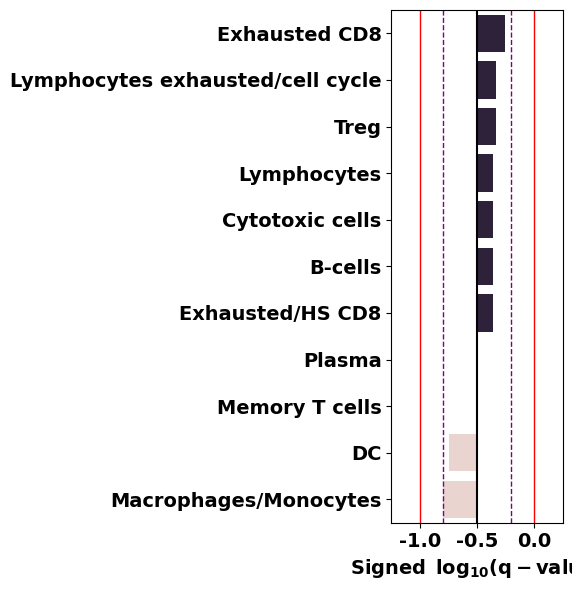


[2/2] Plotting ZI (Myeloid Subsets)...


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

✓ Saved: Fig_Myeloid_Subsets_Exact.png


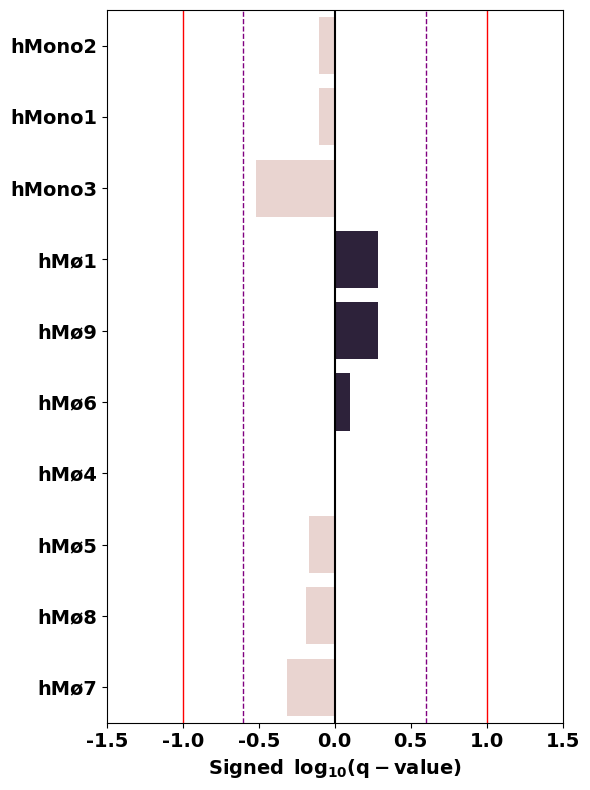


TOP SIGNIFICANT FEATURES (q < 0.1):

>>> SF (Immune Cell Subsets): 0 features

>>> ZI (Myeloid Subsets): 0 features

✅ DONE!


In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib. pyplot as plt
import statsmodels.api as sm
import statsmodels.stats.multitest as multi
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# FUNCTIONS
# ============================================================================

def response_rate_logit(x, y):
    """Y CHANG function từ notebook (line 139-141)"""
    log_reg = sm.Logit(y, sm.add_constant(x)).fit(method='lbfgs', maxiter=99999, disp=0)
    return log_reg. pvalues, log_reg.params


# ============================================================================
# SET PATHS
# ============================================================================

source_data_path =  "/mnt/digphat/syntheticDataBenchmark/Chuong_pipeline/ExperimentNSCLC/LungCancer_ICB/Source Data/"

source_data_path_clinical = source_data_path + 'Clinical/'
source_data_path_rna = source_data_path + 'RNA/'

print("=" * 70)
print("LOADING DATA FROM SU2C-MARK SOURCE FILES...")
print("=" * 70)


# ============================================================================
# READ DATA
# ============================================================================

# Clinical Data
print("\n[1/3] Loading Clinical Data...")
annot_file = 'Table_S1_Clinical_Annotations.xlsx'
su2c_clinical = pd.read_excel(source_data_path_clinical + annot_file, skiprows=2)
print(f"✓ Clinical data:  {su2c_clinical.shape}")

su2c_clinical_extra = pd.read_csv(
    source_data_path_clinical + 'SU2C-MARK_Harmonized_Clinical_Annotations_Supplement_v1.txt',
    sep='\t'
)
print(f"✓ Clinical extra:  {su2c_clinical_extra.shape}")

# SF Scores
print("\n[2/3] Loading SF Scores...")
su2c_is_sf_harm = pd.read_csv(
    source_data_path_rna + 'SU2C-MARK_Harmonized_Curated_Sets_SF_v1.txt',
    sep='\t'
)
print(f"✓ SF scores: {su2c_is_sf_harm.shape}")
print(f"  Columns: {su2c_is_sf_harm.columns.tolist()}")

# ZI Scores
print("\n[3/3] Loading ZI Scores...")
su2c_is_zi_harm = pd.read_csv(
    source_data_path_rna + 'SU2C-MARK_Harmonized_Curated_Sets_ZI_v1.txt',
    sep='\t'
)
print(f"✓ ZI scores: {su2c_is_zi_harm. shape}")
print(f"  Columns: {su2c_is_zi_harm.columns. tolist()}")


# ============================================================================
# RENAME COLUMNS - CÁCH ĐÚNG
# ============================================================================

print("\n" + "=" * 70)
print("RENAMING COLUMNS...")
print("=" * 70)

# Lấy tên cột ID
id_col = 'Harmonized_SU2C_RNA_Tumor_Sample_ID_v2'

# SF:  Chỉ rename feature columns, GIỮ NGUYÊN ID column
sf_feature_cols = [col for col in su2c_is_sf_harm.columns if col != id_col]
sf_rename_dict = {col: col + '_SF' for col in sf_feature_cols}
su2c_is_sf_renamed = su2c_is_sf_harm.rename(columns=sf_rename_dict)

print(f"✓ SF renamed:")
print(f"  ID column (unchanged): {id_col}")
print(f"  Feature columns (added _SF): {list(sf_rename_dict.keys())[:3]} ...")

# ZI: Chỉ rename feature columns, GIỮ NGUYÊN ID column
zi_feature_cols = [col for col in su2c_is_zi_harm. columns if col != id_col]
zi_rename_dict = {col: col + '_ZI' for col in zi_feature_cols}
su2c_is_zi_renamed = su2c_is_zi_harm.rename(columns=zi_rename_dict)

print(f"✓ ZI renamed:")
print(f"  ID column (unchanged): {id_col}")
print(f"  Feature columns (added _ZI): {list(zi_rename_dict.keys())[:3]} ...")


# ============================================================================
# MERGE DATA - CÁCH ĐÚNG
# ============================================================================

print("\n" + "=" * 70)
print("MERGING DATA...")
print("=" * 70)

# Merge clinical + clinical_extra
su2c_merge_master = su2c_clinical.merge(
    su2c_clinical_extra,
    left_on='Harmonized_SU2C_Participant_ID_v2',
    right_on='Harmonized_SU2C_Participant_ID_v2',
    how='inner'
)
print(f"✓ After clinical merge: {su2c_merge_master.shape}")

# Merge SF - DÙNG ĐÚNG TÊN CỘT
su2c_merge_master = su2c_merge_master.merge(
    su2c_is_sf_renamed,
    left_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2',
    right_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2',  # ← ĐÚNG!  Không có _SF
    how='left'
)
print(f"✓ After SF merge: {su2c_merge_master.shape}")

# Check merge success
n_sf_merged = su2c_merge_master[[col for col in su2c_merge_master.columns if '_SF' in col]].notna().any(axis=1).sum()
print(f"  → {n_sf_merged} samples have SF data")

# Merge ZI - DÙNG ĐÚNG TÊN CỘT
su2c_merge_master = su2c_merge_master.merge(
    su2c_is_zi_renamed,
    left_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2',
    right_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2',  # ← ĐÚNG!  Không có _ZI
    how='left'
)
print(f"✓ After ZI merge: {su2c_merge_master.shape}")

# Check merge success
n_zi_merged = su2c_merge_master[[col for col in su2c_merge_master.columns if '_ZI' in col]].notna().any(axis=1).sum()
print(f"  → {n_zi_merged} samples have ZI data")

# Check response column
print(f"\n✓ Response column: 'Harmonized_Confirmed_BOR_Bin'")
print(f"  Distribution:")
print(su2c_merge_master['Harmonized_Confirmed_BOR_Bin'].value_counts())
response_rate = su2c_merge_master['Harmonized_Confirmed_BOR_Bin'].mean()
print(f"  Response rate: {response_rate * 100:.1f}%")


# ============================================================================
# DEFINE FEATURE LISTS
# ============================================================================

print("\n" + "=" * 70)
print("DEFINING FEATURE LISTS...")
print("=" * 70)

# SF features (đã có _SF suffix)
sf_features_renamed = list(sf_rename_dict.values())
print(f"\n✓ SF features ({len(sf_features_renamed)}):")
for feat in sf_features_renamed: 
    print(f"  - {feat}")

# ZI features (đã có _ZI suffix)
zi_features_renamed = list(zi_rename_dict. values())
print(f"\n✓ ZI features ({len(zi_features_renamed)}):")
for feat in zi_features_renamed:
    print(f"  - {feat}")


# ============================================================================
# LOGISTIC REGRESSION
# ============================================================================

print("\n" + "=" * 70)
print("CALCULATING LOGISTIC REGRESSION...")
print("=" * 70)

def calculate_logistic_regression_exact(df, feature_list, response_col='Harmonized_Confirmed_BOR_Bin'):
    """Y CHANG logic từ notebook (line 257-293)"""
    log_reg = []
    
    for feature in feature_list:
        # Set index và lấy feature
        X = df. set_index('Harmonized_SU2C_Participant_ID_v2')[[feature]]
        y = df.set_index('Harmonized_SU2C_Participant_ID_v2')[response_col]
        
        # Merge và dropna
        Xy = X.merge(y, left_index=True, right_index=True, how='inner').dropna()
        
        if len(Xy) < 10:
            print(f"⚠ Warning: {feature} has only {len(Xy)} samples, skipping...")
            continue
        
        X_clean = Xy.iloc[:, [0]]
        y_clean = Xy.iloc[:, [1]]
        
        # Check if categorical
        if X_clean.iloc[:, 0].dtype.name != 'float64':
            print(f"⚠ Note: {feature} is categorical - using get_dummies")
            Xd = pd.get_dummies(X_clean, dummy_na=True).iloc[:, 0:-1]
            
            for col in Xd.columns:
                Xi = Xd[[col]]
                try:
                    p, param = response_rate_logit(Xi, y_clean)
                    log_reg.append([col, p[1], param[1], len(Xy)])
                except Exception as e:
                    print(f"⚠ Warning: {col} failed - {str(e)}")
                    continue
        else:
            # Continuous
            try:
                p, param = response_rate_logit(X_clean, y_clean)
                log_reg.append([feature, p[1], param[1], len(Xy)])
            except Exception as e: 
                print(f"⚠ Warning: {feature} failed - {str(e)}")
                continue
    
    # Create DataFrame
    log_reg_df = pd.DataFrame(log_reg, columns=['Feature', 'p_value', 'coeff', 'N']).set_index('Feature')
    
    # FDR correction
    log_reg_df['q_value'] = multi.multipletests(log_reg_df['p_value'], method='fdr_bh')[1]
    
    return log_reg_df


# SF (Immune Cell Subsets)
print("\n[1/2] Processing SF (Immune Cell Subsets)...")
sf_results = calculate_logistic_regression_exact(su2c_merge_master, sf_features_renamed)
print(f"✓ Completed {len(sf_results)} features")
print(f"  - Significant (q < 0.1): {(sf_results['q_value'] < 0.1).sum()}")
print(f"  - Near-significant (q < 0.25): {(sf_results['q_value'] < 0.25).sum()}")

# ZI (Myeloid Subsets)
print("\n[2/2] Processing ZI (Myeloid Subsets)...")
zi_results = calculate_logistic_regression_exact(su2c_merge_master, zi_features_renamed)
print(f"✓ Completed {len(zi_results)} features")
print(f"  - Significant (q < 0.1): {(zi_results['q_value'] < 0.1).sum()}")
print(f"  - Near-significant (q < 0.25): {(zi_results['q_value'] < 0.25).sum()}")


# ============================================================================
# PREPARE FOR PLOTTING
# ============================================================================

print("\n" + "=" * 70)
print("PREPARING FOR PLOTTING...")
print("=" * 70)

# SF: Sort by signed log10(q-value)
sf_results['Signed log10(q-value)'] = -np.log10(sf_results['q_value']) * np.sign(sf_results['coeff'])
sf_results['hue'] = np.sign(sf_results['coeff'])
sf_results_sorted = sf_results.sort_values('Signed log10(q-value)', ascending=False)

# ZI: Sort theo thứ tự notebook
zi_results['Signed log10(q-value)'] = -np.log10(zi_results['q_value']) * np.sign(zi_results['coeff'])
zi_results['hue'] = np.sign(zi_results['coeff'])

myeloid_order = ['hMono2_ZI', 'hMono1_ZI', 'hMono3_ZI', 
                 'hMø1_ZI', 'hMø9_ZI', 'hMø6_ZI', 'hMø4_ZI', 
                 'hMø5_ZI', 'hMø8_ZI', 'hMø7_ZI',
                 'hN2_ZI', 'hN1_ZI', 'hN5_ZI', 'hN3_ZI',
                 'hDC2_ZI', 'hDC1_ZI', 'hpDC_ZI', 'hDC3_ZI']

available_myeloid = [f for f in myeloid_order if f in zi_results.index]
zi_results_sorted = zi_results. loc[available_myeloid]


# ============================================================================
# PLOTTING
# ============================================================================

print("\n" + "=" * 70)
print("PLOTTING...")
print("=" * 70)

# SF Plot
print("\n[1/2] Plotting SF (Immune Cell Subsets)...")
plt.figure(figsize=(6, 6))

sf_labels = [feat. replace('_SF', '') for feat in sf_results_sorted.index]

h = sns.barplot(
    y=sf_labels,
    x=sf_results_sorted['Signed log10(q-value)'], 
    orient='h',
    hue=sf_results_sorted['hue'], 
    dodge=False
)

ax = plt.gca()
ymin, ymax = ax.get_ylim()

plt.vlines(x=0, ymin=ymin, ymax=ymax, colors='k')
ax.axvline(linewidth=1, x=-np.log10(0.1), linestyle='-', c='r')
ax.axvline(linewidth=1, x=-np. log10(0.25), linestyle='dashed', c='purple')
ax.axvline(linewidth=1, x=np.log10(0.1), linestyle='-', c='r')
ax.axvline(linewidth=1, x=np.log10(0.25), linestyle='dashed', c='purple')

plt.ylabel(None)
plt.setp(ax.get_yticklabels(), font='Arial', fontsize=14, weight='bold')
plt.xlim(-1.5, 1.5)
plt.ylim(len(sf_results_sorted) - 0.5, -0.5)

plt.xlabel('$\\mathregular{Signed\\hspace{0.5}log_{10}(q-value)}$', 
           weight='bold', fontsize=14)
ax.set_xticklabels(ax.get_xticks(), font='Arial', weight='bold', fontsize=14)

if h.legend_:
    h.legend_. remove()

plt.tight_layout()
plt.savefig('Fig_Immune_Cell_Subsets_Exact.png', dpi=300, bbox_inches='tight')
print("✓ Saved:  Fig_Immune_Cell_Subsets_Exact.png")
plt.show()

# ZI Plot
print("\n[2/2] Plotting ZI (Myeloid Subsets)...")
plt.figure(figsize=(6, 8))

zi_labels = [feat.replace('_ZI', '') for feat in zi_results_sorted.index]

h = sns. barplot(
    y=zi_labels,
    x=zi_results_sorted['Signed log10(q-value)'], 
    orient='h',
    hue=zi_results_sorted['hue'], 
    dodge=False
)

ax = plt.gca()
ymin, ymax = ax.get_ylim()

plt.vlines(x=0, ymin=ymin, ymax=ymax, colors='k')
ax.axvline(linewidth=1, x=-np.log10(0.1), linestyle='-', c='r')
ax.axvline(linewidth=1, x=-np.log10(0.25), linestyle='dashed', c='purple')
ax.axvline(linewidth=1, x=np.log10(0.1), linestyle='-', c='r')
ax.axvline(linewidth=1, x=np.log10(0.25), linestyle='dashed', c='purple')

plt.ylabel(None)
plt.setp(ax.get_yticklabels(), font='Arial', fontsize=14, weight='bold')
plt.xlim(-1.5, 1.5)
plt.ylim(len(zi_results_sorted) - 0.5, -0.5)

plt.xlabel('$\\mathregular{Signed\\hspace{0.5}log_{10}(q-value)}$', 
           weight='bold', fontsize=14)
ax.set_xticklabels(ax.get_xticks(), font='Arial', weight='bold', fontsize=14)

if h.legend_:
    h.legend_.remove()

plt.tight_layout()
plt.savefig('Fig_Myeloid_Subsets_Exact.png', dpi=300, bbox_inches='tight')
print("✓ Saved: Fig_Myeloid_Subsets_Exact.png")
plt.show()


# ============================================================================
# SUMMARY
# ============================================================================

sf_sig = sf_results_sorted[sf_results_sorted['q_value'] < 0.1]
zi_sig = zi_results_sorted[zi_results_sorted['q_value'] < 0.1]

print("\n" + "=" * 70)
print("TOP SIGNIFICANT FEATURES (q < 0.1):")
print("=" * 70)

print(f"\n>>> SF (Immune Cell Subsets): {len(sf_sig)} features")
for feat, row in sf_sig.iterrows():
    direction = "↑ Favorable" if row['coeff'] > 0 else "↓ Unfavorable"
    print(f"  {feat. replace('_SF', ''): <35}:  {direction: >15} (coeff={row['coeff']: >7.3f}, q={row['q_value']:.4f}, N={row['N']})")

print(f"\n>>> ZI (Myeloid Subsets): {len(zi_sig)} features")
for feat, row in zi_sig.iterrows():
    direction = "↑ Favorable" if row['coeff'] > 0 else "↓ Unfavorable"
    print(f"  {feat.replace('_ZI', ''):<35}: {direction:>15} (coeff={row['coeff']:>7.3f}, q={row['q_value']:.4f}, N={row['N']})")

print("\n" + "=" * 70)
print("✅ DONE!")
print("=" * 70)

Loaded:
  clinical: (393, 38)
  clinical_extra: (393, 7)
  SF: (152, 12)
  ZI: (152, 11)
  ZI_Ext: (152, 13)
Merged master: (393, 77)
BOR_Bin distribution:
Harmonized_Confirmed_BOR_Bin
0.0    235
1.0    142
NaN     16
Name: count, dtype: int64

#SF features: 11
#ZI union features: 22
Total select_cols: 33


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f


log_reg_df shape: (33, 3)


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


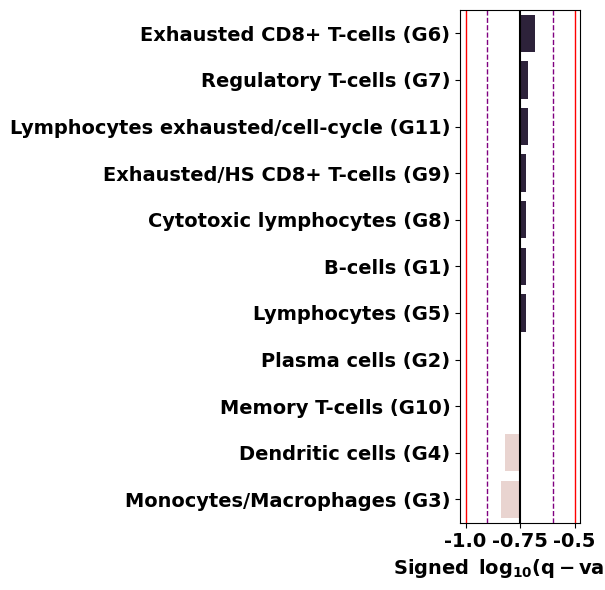

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

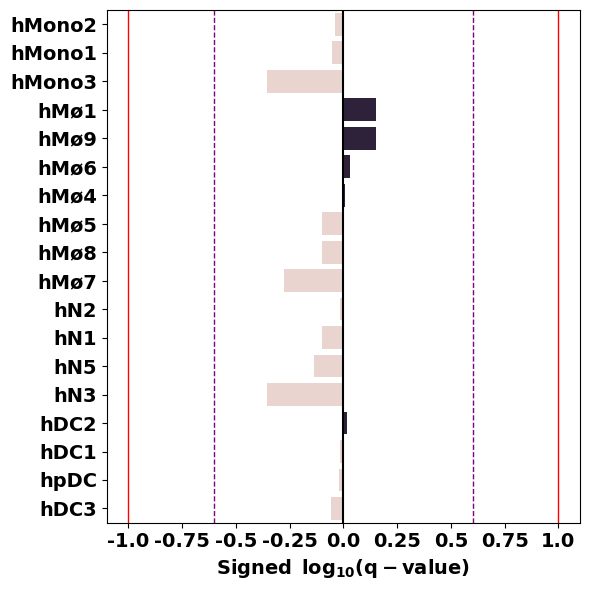

In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.stats.multitest as multi
import warnings
warnings.filterwarnings("ignore")

# =============================================================================
# 1) FUNCTIONS (y chang notebook)
# =============================================================================
def response_rate_logit(x, y):
    log_reg = sm.Logit(y, sm.add_constant(x)).fit(method="lbfgs", maxiter=99999, disp=0)
    return log_reg.pvalues, log_reg.params


# =============================================================================
# 2) PATHS
# =============================================================================
# source_data_path = ".../Source Data/"   # <-- đổi path này
source_data_path = "/mnt/digphat/syntheticDataBenchmark/Chuong_pipeline/ExperimentNSCLC/LungCancer_ICB/Source Data/"
source_data_path_clinical = source_data_path + "Clinical/"
source_data_path_rna = source_data_path + "RNA/"


# =============================================================================
# 3) LOAD DATA
# =============================================================================
annot_file = "Table_S1_Clinical_Annotations.xlsx"
su2c_clinical = pd.read_excel(source_data_path_clinical + annot_file, skiprows=2)

su2c_clinical_extra = pd.read_csv(
    source_data_path_clinical + "SU2C-MARK_Harmonized_Clinical_Annotations_Supplement_v1.txt",
    sep="\t",
)

su2c_is_sf_harm = pd.read_csv(
    source_data_path_rna + "SU2C-MARK_Harmonized_Curated_Sets_SF_v1.txt",
    sep="\t",
)

su2c_is_zi_harm = pd.read_csv(
    source_data_path_rna + "SU2C-MARK_Harmonized_Curated_Sets_ZI_v1.txt",
    sep="\t",
)

# IMPORTANT: ZI extended
su2c_is_zi_ext_harm = pd.read_csv(
    source_data_path_rna + "SU2C-MARK_Harmonized_Curated_Sets_ZI_Extended_v1.txt",
    sep="\t",
)

print("Loaded:")
print("  clinical:", su2c_clinical.shape)
print("  clinical_extra:", su2c_clinical_extra.shape)
print("  SF:", su2c_is_sf_harm.shape)
print("  ZI:", su2c_is_zi_harm.shape)
print("  ZI_Ext:", su2c_is_zi_ext_harm.shape)


# =============================================================================
# 4) MERGE MASTER (đúng notebook: merge SF + ZI + ZI_Extended)
# =============================================================================
su2c_merge_master = (
    su2c_clinical.merge(
        su2c_clinical_extra,
        left_on="Harmonized_SU2C_Participant_ID_v2",
        right_on="Harmonized_SU2C_Participant_ID_v2",
        how="inner",
    )
    .merge(
        su2c_is_sf_harm.rename(columns=lambda x: x + "_SF"),
        left_on="Harmonized_SU2C_RNA_Tumor_Sample_ID_v2",
        right_on="Harmonized_SU2C_RNA_Tumor_Sample_ID_v2_SF",
        how="left",
    )
    .drop("Harmonized_SU2C_RNA_Tumor_Sample_ID_v2_SF", axis=1)
    .merge(
        su2c_is_zi_harm.rename(columns=lambda x: x + "_ZI"),
        left_on="Harmonized_SU2C_RNA_Tumor_Sample_ID_v2",
        right_on="Harmonized_SU2C_RNA_Tumor_Sample_ID_v2_ZI",
        how="left",
    )
    .drop("Harmonized_SU2C_RNA_Tumor_Sample_ID_v2_ZI", axis=1)
    .merge(
        su2c_is_zi_ext_harm.rename(columns=lambda x: x + "_ZI"),
        left_on="Harmonized_SU2C_RNA_Tumor_Sample_ID_v2",
        right_on="Harmonized_SU2C_RNA_Tumor_Sample_ID_v2_ZI",
        how="left",
    )
    .drop("Harmonized_SU2C_RNA_Tumor_Sample_ID_v2_ZI", axis=1)
)

# print("\nMerged master:", su2clying between loops??)
print("Merged master:", su2c_merge_master.shape)
print("BOR_Bin distribution:")
print(su2c_merge_master["Harmonized_Confirmed_BOR_Bin"].value_counts(dropna=False))


# =============================================================================
# 5) BUILD select_cols (SF + (ZI union ZI_Extended))
# =============================================================================
sf_feature_cols = [c + "_SF" for c in su2c_is_sf_harm.columns[1:]]

# union ZI + ZI_Extended (loại bỏ duplicate)
zi_union_cols = list(dict.fromkeys(list(su2c_is_zi_harm.columns[1:]) + list(su2c_is_zi_ext_harm.columns[1:])))
zi_feature_cols = [c + "_ZI" for c in zi_union_cols]

select_cols = sf_feature_cols + zi_feature_cols

print("\n#SF features:", len(sf_feature_cols))
print("#ZI union features:", len(zi_feature_cols))
print("Total select_cols:", len(select_cols))


# =============================================================================
# 6) LOGISTIC REGRESSION (y chang notebook cell)
# =============================================================================
log_reg = []
df_test = su2c_merge_master

for feature in select_cols:
    X = df_test.set_index("Harmonized_SU2C_Participant_ID_v2").loc[:, [feature]]

    if X.iloc[:, 0].dtype.name != "float64":
        Xd = pd.get_dummies(X, dummy_na=True).iloc[:, 0:-1]
        for col in Xd.columns:
            y = df_test.set_index("Harmonized_SU2C_Participant_ID_v2")["Harmonized_Confirmed_BOR_Bin"]
            Xi = Xd[[col]]
            Xy = Xi.merge(y, left_index=True, right_index=True, how="inner").dropna()
            Xi2 = Xy.iloc[:, [0]]
            y2 = Xy.iloc[:, [1]]
            p, param = response_rate_logit(Xi2, y2)
            log_reg.append([Xi2.columns[0], p[1], param[1]])
    else:
        y = df_test.set_index("Harmonized_SU2C_Participant_ID_v2")["Harmonized_Confirmed_BOR_Bin"]
        Xy = X.merge(y, left_index=True, right_index=True, how="inner").dropna()
        X2 = Xy.iloc[:, [0]]
        y2 = Xy.iloc[:, [1]]
        p, param = response_rate_logit(X2, y2)
        log_reg.append([feature, p[1], param[1]])

log_reg_df = pd.DataFrame(log_reg, columns=["Feature", "p_value", "coeff"]).set_index("Feature")
log_reg_df["q_value"] = multi.multipletests(log_reg_df["p_value"], method="fdr_bh")[1]

print("\nlog_reg_df shape:", log_reg_df.shape)


# =============================================================================
# 7) FIGURE: Immune Cell Subsets (SF) (y chang notebook)
# =============================================================================
df_plot = log_reg_df.loc[su2c_is_sf_harm.columns[1:] + "_SF"].copy()
df_plot = df_plot.sort_values("coeff", ascending=False)

sf_cols_rename = [
    "Exhausted CD8+ T-cells (G6)",
    "Regulatory T-cells (G7)",
    "Lymphocytes exhausted/cell-cycle (G11)",
    "Exhausted/HS CD8+ T-cells (G9)",
    "Cytotoxic lymphocytes (G8)",
    "B-cells (G1)",
    "Lymphocytes (G5)",
    "Plasma cells (G2)",
    "Memory T-cells (G10)",
    "Dendritic cells (G4)",
    "Monocytes/Macrophages (G3)",
]

df_plot["Signed log10(q-value)"] = -np.log10(df_plot["q_value"]) * np.sign(df_plot["coeff"])
df_plot = df_plot.sort_values("Signed log10(q-value)", ascending=False)
df_plot["hue"] = np.sign(df_plot["coeff"])
df_plot.index = sf_cols_rename

plt.figure(figsize=(6, 6))
h = sns.barplot(
    y=df_plot.index,
    x=df_plot["Signed log10(q-value)"],
    orient="h",
    hue=df_plot["hue"],
    dodge=False,
)

ax = plt.gca()
ymin, ymax = ax.get_ylim()
plt.vlines(x=0, ymin=ymin, ymax=ymax, colors="k")
ax.axvline(linewidth=1, x=-np.log10(0.1), linestyle="-", c="r")
ax.axvline(linewidth=1, x=-np.log10(0.25), linestyle="dashed", c="purple")
ax.axvline(linewidth=1, x=np.log10(0.1), linestyle="-", c="r")
ax.axvline(linewidth=1, x=np.log10(0.25), linestyle="dashed", c="purple")

plt.ylabel(None)
plt.setp(ax.get_yticklabels(), font="Arial", fontsize=14, weight="bold")
plt.setp(ax.get_xticklabels(), fontsize=12)
plt.ylim(10.5, -0.5)

plt.xlabel("$\\mathregular{Signed\\hspace{0.5}log_{10}(q-value)}$", weight="bold", fontsize=14)
ax.set_xticklabels(ax.get_xticks(), font="Arial", weight="bold", fontsize=14)
h.legend_.remove()

plt.tight_layout()
plt.show()


# =============================================================================
# 8) FIGURE: Myeloid Subsets (ZI) (y chang notebook)
# =============================================================================
mphage_subsets = [
    "hMø1","hMø4","hMø5","hMø6","hMø7","hMø8","hMø9",
    "hMono1","hMono2","hMono3",
    "hN1","hN2","hN3","hN5",
    "hDC1","hDC2","hDC3","hpDC"
]

df_plot = log_reg_df.loc[[name + "_ZI" for name in mphage_subsets]].copy()
df_plot = df_plot.sort_values("coeff", ascending=False)

df_plot["Signed log10(q-value)"] = -np.log10(df_plot["q_value"]) * np.sign(df_plot["coeff"])
df_plot = df_plot.sort_values("Signed log10(q-value)", ascending=False)
df_plot["hue"] = np.sign(df_plot["coeff"])

df_plot.index = [name.split("_")[0] for name in df_plot.index]

df_plot = df_plot.loc[
    [
        "hMono2","hMono1","hMono3",
        "hMø1","hMø9","hMø6","hMø4","hMø5","hMø8","hMø7",
        "hN2","hN1","hN5","hN3",
        "hDC2","hDC1","hpDC","hDC3",
    ]
]

plt.figure(figsize=(6, 6))
h = sns.barplot(
    y=df_plot.index,
    x=df_plot["Signed log10(q-value)"],
    orient="h",
    hue=df_plot["hue"],
    dodge=False,
)

ax = plt.gca()
ymin, ymax = ax.get_ylim()
plt.vlines(x=0, ymin=ymin, ymax=ymax, colors="k")
ax.axvline(linewidth=1, x=-np.log10(0.1), linestyle="-", c="r")
ax.axvline(linewidth=1, x=-np.log10(0.25), linestyle="dashed", c="purple")
ax.axvline(linewidth=1, x=np.log10(0.1), linestyle="-", c="r")
ax.axvline(linewidth=1, x=np.log10(0.25), linestyle="dashed", c="purple")

plt.ylabel(None)
plt.setp(ax.get_yticklabels(), font="Arial", fontsize=14, weight="bold")
plt.setp(ax.get_xticklabels(), fontsize=12)
plt.ylim(17.5, -0.5)

plt.xlabel("$\\mathregular{Signed\\hspace{0.5}log_{10}(q-value)}$", weight="bold", fontsize=14)
ax.set_xticklabels(ax.get_xticks(), font="Arial", weight="bold", fontsize=14)
h.legend_.remove()

plt.tight_layout()
plt.show()